In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
x=dataset.iloc[:,[3,4]].values

In [5]:
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  

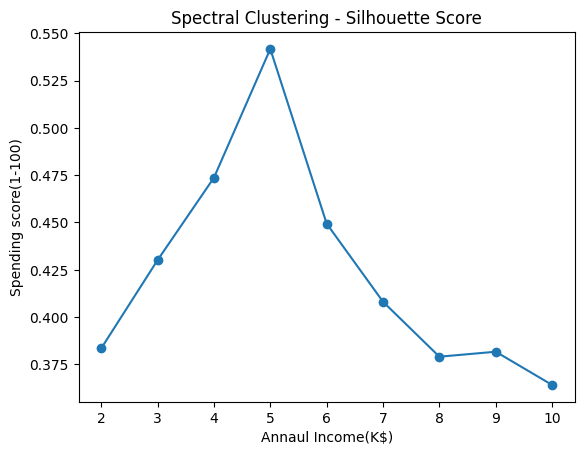

In [14]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score


silhouette_scores = []

for i in range(2, 11):
    sc = SpectralClustering(
        n_clusters=i,
        affinity='nearest_neighbors',   # or 'rbf'
        n_neighbors=10,
        random_state=0
    )
    
    y_pred = sc.fit_predict(x)
    
    # Safe check (avoid error)
    if len(set(y_pred)) > 1:
        score = silhouette_score(x, y_pred)
    else:
        score = np.nan
    
    silhouette_scores.append(score)

plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Spectral Clustering - Silhouette Score")
plt.xlabel("Annaul Income(K$)")
plt.ylabel("Spending score(1-100)")
plt.show()

In [7]:
y_pred=sc.fit_predict(x)

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [8]:
y_pred

array([7, 2, 6, 2, 7, 2, 6, 2, 6, 2, 6, 2, 6, 2, 6, 2, 7, 2, 7, 2, 7, 2,
       6, 2, 6, 2, 7, 2, 7, 2, 6, 2, 6, 2, 6, 2, 6, 2, 7, 2, 7, 2, 7, 0,
       7, 0, 0, 7, 7, 7, 0, 0, 0, 0, 7, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4, 4, 0, 0, 3, 3,
       3, 4, 3, 4, 3, 4, 4, 3, 4, 3, 4, 3, 4, 3, 3, 3, 3, 4, 3, 4, 4, 3,
       3, 3, 4, 4, 4, 3, 4, 3, 4, 3, 3, 4, 3, 1, 4, 8, 4, 1, 9, 8, 9, 8,
       4, 8, 9, 1, 9, 8, 9, 8, 9, 1, 4, 1, 9, 1, 4, 8, 5, 1, 5, 1, 5, 8,
       9, 1, 9, 8, 9, 8, 4, 1, 9, 1, 5, 8, 5, 1, 5, 8, 5, 8, 5, 1, 5, 1,
       5, 8, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 1,
       5, 1], dtype=int32)

In [9]:
from sklearn.metrics import silhouette_score
score=silhouette_score(x,y_pred)

In [10]:
score

0.36419778640630723

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


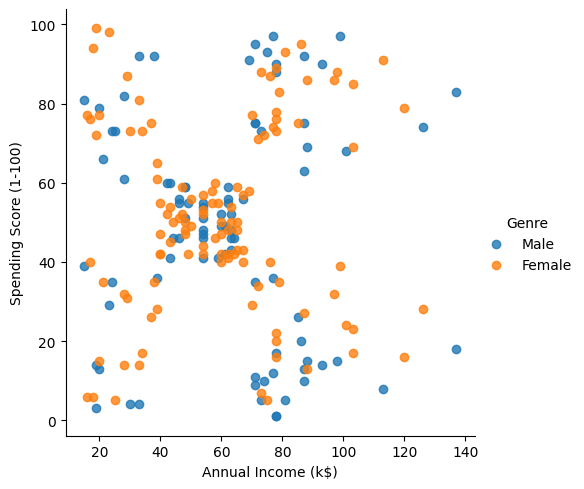

In [11]:
import seaborn as sns
facet = sns.lmplot(
    data = dataset,
       x = dataset.columns[3],
       y = dataset.columns[4],
     hue = dataset.columns[1],
  fit_reg= False,
  legend = True,
legend_out = True)